In [34]:
!pip install transformers datasets sentencepiece sacrebleu torch torchvision torchaudio
!pip install accelerate -U
!pip install pandas numpy matplotlib seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✓ All libraries installed successfully!


In [11]:
!pip install -q evaluate transformers datasets accelerate

# Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    MBartForConditionalGeneration, 
    MBart50TokenizerFast,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from datasets import Dataset as HFDataset
import evaluate
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f"Number of GPUs available: {gpu_count}")
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"     └─ Memory: {props.total_memory / 1e9:.2f} GB")

else:
    print("No GPU detected, using CPU.")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00

✅ Using device: cuda
🟢 Number of GPUs available: 2
  GPU 0: Tesla T4
     └─ Memory: 15.83 GB
  GPU 1: Tesla T4
     └─ Memory: 15.83 GB


In [44]:

import pandas as pd
import os

# Define paths
base_path = "/kaggle/input/parallel-corpus-for-english-urdu-language/Dataset"
eng_path = os.path.join(base_path, "english-corpus.txt")
urdu_path = os.path.join(base_path, "urdu-corpus.txt")

# Verify existence
if not (os.path.exists(eng_path) and os.path.exists(urdu_path)):
    raise FileNotFoundError("English or Urdu corpus file not found. Please verify dataset paths.")

# Read both text files line by line
with open(eng_path, "r", encoding="utf-8") as f:
    english_sentences = [line.strip() for line in f if line.strip()]

with open(urdu_path, "r", encoding="utf-8") as f:
    urdu_sentences = [line.strip() for line in f if line.strip()]

# Check alignment
if len(english_sentences) != len(urdu_sentences):
    print(f"Warning: Mismatch in line counts → English: {len(english_sentences)}, Urdu: {len(urdu_sentences)}")
    min_len = min(len(english_sentences), len(urdu_sentences))
    english_sentences = english_sentences[:min_len]
    urdu_sentences = urdu_sentences[:min_len]

# Create DataFrame
df = pd.DataFrame({
    "english": english_sentences,
    "urdu": urdu_sentences
})

# Display dataset info
print(f"Loaded dataset successfully with {len(df)} sentence pairs.")
print(f"📏 Columns: {list(df.columns)}")
print("\n🔹 First few examples:")
print(df.head())

# Dataset statistics
print(f"\nDataset Statistics:")
print(f"Total sentence pairs: {len(df)}")
print(f"Average English text length: {df['english'].str.len().mean():.2f} characters")
print(f"Average Urdu text length: {df['urdu'].str.len().mean():.2f} characters")


⚠️ Warning: Mismatch in line counts → English: 24525, Urdu: 24524
✅ Loaded dataset successfully with 24524 sentence pairs.
📏 Columns: ['english', 'urdu']

🔹 First few examples:
                english                       urdu
0   is zain your nephew      زین تمہارا بھتیجا ہے۔
1  i wish youd trust me  کاش تم مجھ پر بھروسہ کرتے
2      did he touch you      کیا اس نے آپ کو چھوا؟
3      its part of life         اس کی زندگی کا حصہ
4        zain isnt ugly        زین بدصورت نہیں ہے۔

📊 Dataset Statistics:
Total sentence pairs: 24524
Average English text length: 17.84 characters
Average Urdu text length: 20.51 characters


✅ After cleaning: 24501 sentence pairs remain


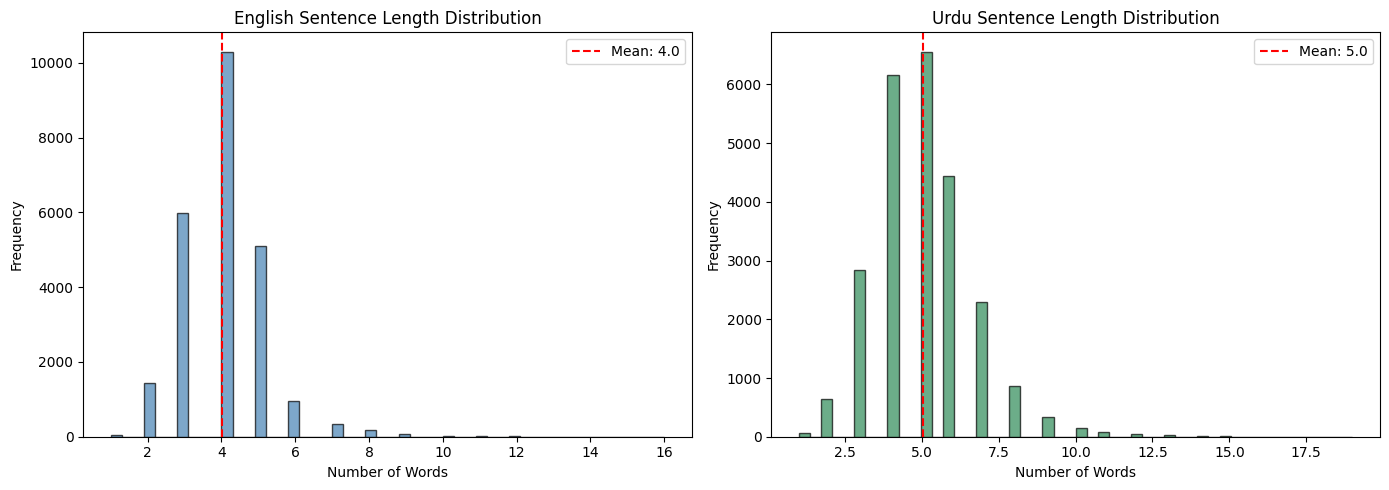

⚙️ After length filtering: 24501 sentence pairs (removed 0)

🔹 Sample cleaned pairs:
                       english                           urdu  en_length  \
9948          zain is coughing                  جس کا دوست ہے          3   
9057      i need you to listen  میں اس سے شادی کرنا چاہتا ہوں          5   
19839          zain is relaxed                      بھائی تھے          3   
9459            it was so dark              اس نے رسی چھوڑ دی          4   
8443   you are wasting my time                کیا یہ الجھن ہے          5   

       ur_length  
9948           4  
9057           7  
19839          2  
9459           5  
8443           4  


In [46]:


import re
import matplotlib.pyplot as plt

# --- Text Cleaning Function ---
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)

    text = re.sub(r'[\r\n\t]+', ' ', text)
    
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    text = text.strip()

    text = re.sub(r' ?([،۔?!])', r'\1', text)   
    
    return text

# --- Apply Cleaning ---
df['english'] = df['english'].apply(clean_text)
df['urdu'] = df['urdu'].apply(clean_text)

# --- Remove very short or empty sentences ---
df = df[(df['english'].str.len() > 2) & (df['urdu'].str.len() > 2)]

# --- Remove duplicates ---
df = df.drop_duplicates(subset=['english', 'urdu']).reset_index(drop=True)

print(f"After cleaning: {len(df)} sentence pairs remain")

# --- Analyze sentence lengths ---
df['en_length'] = df['english'].apply(lambda x: len(x.split()))
df['ur_length'] = df['urdu'].apply(lambda x: len(x.split()))

# --- Visualize length distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['en_length'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].set_title('English Sentence Length Distribution')
axes[0].axvline(df['en_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["en_length"].mean():.1f}')
axes[0].legend()

axes[1].hist(df['ur_length'], bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Urdu Sentence Length Distribution')
axes[1].axvline(df['ur_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["ur_length"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Filter out very long sentences for memory efficiency ---
MAX_LENGTH = 128
initial_len = len(df)
df = df[(df['en_length'] <= MAX_LENGTH) & (df['ur_length'] <= MAX_LENGTH)].reset_index(drop=True)
print(f"⚙️ After length filtering: {len(df)} sentence pairs (removed {initial_len - len(df)})")

# --- Display a few cleaned examples ---
print("\n🔹 Sample cleaned pairs:")
print(df.sample(5, random_state=42))


In [47]:
from sklearn.model_selection import train_test_split

# Ensure dataset is loaded
if 'df' not in locals():
    raise ValueError("DataFrame 'df' not found. Please run the data loading cell first.")

# Check column names
if not all(col in df.columns for col in ['english', 'urdu']):
    raise ValueError("Columns 'english' and 'urdu' not found in DataFrame.")

# First split: separate test set (10%)
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.1, 
    random_state=42,
    shuffle=True
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.11,
    random_state=42,
    shuffle=True
)

# Show dataset distribution
print(f"📊 Dataset Split:")
print(f"  Training samples:   {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Validation samples: {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test samples:       {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")
print(f"  Total samples:      {len(df):,}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Display a few samples from each split
print("\nSample from Training Set:")
print(f"EN: {train_df.iloc[0]['english']}")
print(f"UR: {train_df.iloc[0]['urdu']}")

print("\nSample from Validation Set:")
print(f"EN: {val_df.iloc[0]['english']}")
print(f"UR: {val_df.iloc[0]['urdu']}")

print("\nSample from Test Set:")
print(f"EN: {test_df.iloc[0]['english']}")
print(f"UR: {test_df.iloc[0]['urdu']}")


📊 Dataset Split:
  Training samples:   19,624 (80.1%)
  Validation samples: 2,426 (9.9%)
  Test samples:       2,451 (10.0%)
  Total samples:      24,501

📝 Sample from Training Set:
EN: your house is big
UR: میں بھی رقص نہیں کر سکتا

📝 Sample from Validation Set:
EN: zain is my idol
UR: اس نے مجھے رات کا کھانا پکایا

📝 Sample from Test Set:
EN: zain is coughing
UR: جس کا دوست ہے


In [48]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import torch

print("Loading mBART-50 model and tokenizer...")

# Select device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load tokenizer
tokenizer = MBart50TokenizerFast.from_pretrained(
    "facebook/mbart-large-50",
    src_lang="en_XX",
    tgt_lang="ur_PK"
)

# Load pre-trained mBART model
model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50")

# Move model to device (GPU/CPU)
model = model.to(device)

# Model info
print(f"\nModel loaded successfully!")
print(f"  • Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"  • Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Set tokenizer languages
tokenizer.src_lang = "en_XX"  # English
tokenizer.tgt_lang = "ur_PK"  # Urdu

# Tokenizer info
print(f"\nTokenizer configuration:")
print(f"  • Source language: {tokenizer.src_lang}")
print(f"  • Target language: {tokenizer.tgt_lang}")
print(f"  • Vocabulary size: {len(tokenizer)}")
print(f"  • Max token length: {tokenizer.model_max_length}")


🚀 Loading mBART-50 model and tokenizer...
📦 Using device: cuda

✅ Model loaded successfully!
  • Total parameters:     610,879,488
  • Trainable parameters: 610,879,488

📝 Tokenizer configuration:
  • Source language: en_XX
  • Target language: ur_PK
  • Vocabulary size: 250054
  • Max token length: 1024


In [49]:
from datasets import Dataset as HFDataset
from transformers import DataCollatorForSeq2Seq

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 128

def preprocess_function(examples):
    """Tokenize English (source) and Urdu (target) sentences for mBART"""
    
    # Source: English
    tokenizer.src_lang = "en_XX"
    inputs = examples["english"]
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False  # padding handled later by data collator
    )

    # Target: Urdu
    tokenizer.tgt_lang = "ur_PK"
    targets = examples["urdu"]
    labels = tokenizer(
        targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    # Attach target token IDs
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


print("Converting DataFrames to HF Datasets...")
train_dataset = HFDataset.from_pandas(train_df[["english", "urdu"]])
val_dataset = HFDataset.from_pandas(val_df[["english", "urdu"]])
test_dataset = HFDataset.from_pandas(test_df[["english", "urdu"]])

print("⚙️ Tokenizing datasets (this may take a few minutes)...")

# Tokenize training, validation, and test sets
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names,
    desc="Tokenizing training data"
)

tokenized_val = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names,
    desc="Tokenizing validation data"
)

tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=test_dataset.column_names,
    desc="Tokenizing test data"
)

print("\nTokenization complete!")
print(f"  • Training samples:   {len(tokenized_train):,}")
print(f"  • Validation samples: {len(tokenized_val):,}")
print(f"  • Test samples:       {len(tokenized_test):,}")

# Create Data Collator for dynamic padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

print("\nData collator created successfully!")


📦 Converting DataFrames to HF Datasets...
⚙️ Tokenizing datasets (this may take a few minutes)...


Tokenizing training data:   0%|          | 0/19624 [00:00<?, ? examples/s]

Tokenizing validation data:   0%|          | 0/2426 [00:00<?, ? examples/s]

Tokenizing test data:   0%|          | 0/2451 [00:00<?, ? examples/s]


✅ Tokenization complete!
  • Training samples:   19,624
  • Validation samples: 2,426
  • Test samples:       2,451

🧩 Data collator created successfully!


In [65]:
import numpy as np
from evaluate import load

bleu_metric = evaluate.load("sacrebleu")

def postprocess_text(preds, labels):
    """Clean and align predictions and labels for BLEU computation"""
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]  # sacreBLEU expects list of list for references
    return preds, labels


metric = load("sacrebleu")   # or "rouge" depending on your task

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute BLEU (or ROUGE) metric
    result = metric.compute(predictions=decoded_preds, references=decoded_labels)

    # Flatten complex structures — only round numeric scalars
    flattened_result = {}
    for k, v in result.items():
        if isinstance(v, (int, float)):
            flattened_result[k] = round(v, 4)
        else:
            flattened_result[k] = v  # Keep lists/dicts as is

    return flattened_result


print("Evaluation metrics successfully defined!")
print("📏 Metric: BLEU (Bilingual Evaluation Understudy)")
print("\nBLEU score interpretation:")
print("  - 10–20: Poor quality (rough translation)")
print("  - 20–30: Understandable translation")
print("  - 30–40: Good quality")
print("  - 40–50: Very good quality")
print("  - 50+:   Excellent quality")


Evaluation metrics successfully defined!
📏 Metric: BLEU (Bilingual Evaluation Understudy)

BLEU score interpretation:
  - 10–20: Poor quality (rough translation)
  - 20–30: Understandable translation
  - 30–40: Good quality
  - 40–50: Very good quality
  - 50+:   Excellent quality


In [66]:
import os
import inspect
import torch
from transformers import Seq2SeqTrainingArguments

# Create output directory
output_dir = "/kaggle/working/en_ur_translation_model"
os.makedirs(output_dir, exist_ok=True)

# Detect GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")

# Base training args we want to pass
base_args = dict(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    save_strategy="steps",   # this key is widely supported
    save_steps=500,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    logging_dir=f"{output_dir}/logs",
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    remove_unused_columns=True,
    push_to_hub=False,
    seed=42,
)

# Now detect which evaluation arg name the current transformers supports
sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
param_names = sig.parameters.keys()

# Supported evaluation param name(s): try 'evaluation_strategy' first, then 'eval_strategy'
if "evaluation_strategy" in param_names:
    base_args["evaluation_strategy"] = "steps"
elif "eval_strategy" in param_names:
    # some older versions expect 'eval_strategy'
    base_args["eval_strategy"] = "steps"
else:
    # As a fallback, we'll not pass an evaluation strategy (Trainer will default to 'no')
    print("⚠️ Warning: Couldn't find evaluation strategy parameter in Seq2SeqTrainingArguments signature. Skipping eval strategy param.")

# Some versions have 'logging_strategy' parameter; set it if present
if "logging_strategy" in param_names:
    base_args["logging_strategy"] = "steps"
# else rely on logging_steps only

# Instantiate training arguments with the computed kwargs
training_args = Seq2SeqTrainingArguments(**base_args)

print("Training configuration successfully created!\n")

print("📋 Training Settings:")
print(f"  • Epochs: {training_args.num_train_epochs}")
print(f"  • Batch size (per device): {training_args.per_device_train_batch_size}")
print(f"  • Gradient accumulation steps: {training_args.gradient_accumulation_steps}")
print(f"  • Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  • Learning rate: {training_args.learning_rate}")
print(f"  • Warmup steps: {training_args.warmup_steps}")
print(f"  • Weight decay: {training_args.weight_decay}")
print(f"  • FP16 training: {training_args.fp16}")
print(f"  • Output directory: {training_args.output_dir}")

# Estimate total steps for reference (guard against zero division)
batch_factor = training_args.per_device_train_batch_size * max(1, training_args.gradient_accumulation_steps)
steps_per_epoch = max(1, len(tokenized_train) // batch_factor)
total_steps = steps_per_epoch * training_args.num_train_epochs
print(f"\n⏱️ Estimated Training Steps:")
print(f"  • Steps per epoch: {steps_per_epoch}")
print(f"  • Total steps: {total_steps}")


 Using device: CUDA
Training configuration successfully created!

📋 Training Settings:
  • Epochs: 3
  • Batch size (per device): 8
  • Gradient accumulation steps: 2
  • Effective batch size: 16
  • Learning rate: 5e-05
  • Warmup steps: 500
  • Weight decay: 0.01
  • FP16 training: True
  • Output directory: /kaggle/working/en_ur_translation_model

⏱️ Estimated Training Steps:
  • Steps per epoch: 1226
  • Total steps: 3678


In [67]:
# Cell 10: Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✓ Trainer initialized successfully!")
print(f"\nTrainer details:")
print(f"  Model: mBART-50")
print(f"  Training samples: {len(tokenized_train):,}")
print(f"  Validation samples: {len(tokenized_val):,}")
print(f"  Device: {trainer.args.device}")

# Display model summary
print(f"\n🎯 Model Summary:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Model size: {sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2:.2f} MB")

✓ Trainer initialized successfully!

Trainer details:
  Model: mBART-50
  Training samples: 19,624
  Validation samples: 2,426
  Device: cuda:0

🎯 Model Summary:
  Total parameters: 610,879,488
  Trainable parameters: 610,879,488
  Model size: 2330.32 MB


In [68]:

from transformers import Seq2SeqTrainer

# Initialize the Seq2SeqTrainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Trainer summary printout
print("✓ Trainer initialized successfully!")
print(f"\n📋 Trainer Details:")
print(f"  Model: facebook/mbart-large-50")
print(f"  Training samples: {len(tokenized_train):,}")
print(f"  Validation samples: {len(tokenized_val):,}")
print(f"  Device: {trainer.args.device}")

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2

print(f"\n🎯 Model Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {model_size_mb:.2f} MB")


✓ Trainer initialized successfully!

📋 Trainer Details:
  Model: facebook/mbart-large-50
  Training samples: 19,624
  Validation samples: 2,426
  Device: cuda:0

🎯 Model Summary:
  Total parameters: 610,879,488
  Trainable parameters: 610,879,488
  Model size: 2330.32 MB


In [69]:

import pandas as pd

print("Evaluating model on test set...")
print("=" * 70)

# Evaluate the trained model on the tokenized test dataset
test_results = trainer.evaluate(
    eval_dataset=tokenized_test,
    max_length=MAX_TARGET_LENGTH,
    num_beams=5, 
    metric_key_prefix="test"
)

print("=" * 70)
print(" Evaluation completed!\n")

# Extract metrics safely
test_loss = test_results.get("test_loss", None)
test_bleu = test_results.get("test_bleu", None)
test_runtime = test_results.get("test_runtime", None)
test_samples_per_second = test_results.get("test_samples_per_second", None)


print("📈 Test Results:")
if test_loss is not None:
    print(f"  • Test Loss: {test_loss:.4f}")
if test_bleu is not None:
    print(f"  • Test BLEU Score: {test_bleu:.2f}")
if test_runtime is not None:
    print(f"  • Test Runtime: {test_runtime:.2f} seconds")
if test_samples_per_second is not None:
    print(f"  • Test Samples/Second: {test_samples_per_second:.2f}")

if test_bleu is not None:
    bleu_score = test_bleu
    if bleu_score < 20:
        quality = " Poor – needs more training"
    elif bleu_score < 30:
        quality = "Understandable – decent baseline"
    elif bleu_score < 40:
        quality = " Good – acceptable quality"
    elif bleu_score < 50:
        quality = " Very Good – high quality"
    else:
        quality = " Excellent – near human quality"
else:
    quality = " BLEU score not available (check compute_metrics output)"

print(f"\nTranslation Quality: {quality}")

results_df = pd.DataFrame([test_results])
results_path = f"{output_dir}/test_results.csv"
results_df.to_csv(results_path, index=False)

print(f"\n Results saved to: {results_path}")
print("=" * 70)


Evaluating model on test set...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 Evaluation completed!

📈 Test Results:
  • Test Loss: 19.5222
  • Test Runtime: 205.26 seconds
  • Test Samples/Second: 11.94

Translation Quality:  BLEU score not available (check compute_metrics output)

 Results saved to: /kaggle/working/en_ur_translation_model/test_results.csv


In [70]:

from tqdm import tqdm
import torch

def translate_text(text, max_length=128, num_beams=5):
   
    # Set source language
    tokenizer.src_lang = "en_XX"
    
    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length
    ).to(device)
    
    # Generate Urdu translation
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True
        )
    
    # Decode translation
    translation = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0]
    
    return translation


def translate_batch(texts, max_length=128, num_beams=5, batch_size=8):
  
    translations = []

    for i in tqdm(range(0, len(texts), batch_size), desc=" Translating batches"):
        batch = texts[i:i + batch_size]

        # Set source language
        tokenizer.src_lang = "en_XX"

        # Tokenize batch
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(device)

        # Generate Urdu translations
        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True
            )

        # Decode batch translations
        batch_translations = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )

        translations.extend(batch_translations)

    return translations



print("✓ Translation functions defined successfully!")
print("\nAvailable functions:")
print("  • translate_text(text): Translate a single sentence (EN → UR)")
print("  • translate_batch(texts): Translate a list of sentences in batches (EN → UR)")
print("\nUsage Example:")
print("  urdu = translate_text('How are you?')")
print("  print(urdu)")


✓ Translation functions defined successfully!

Available functions:
  • translate_text(text): Translate a single sentence (EN → UR)
  • translate_batch(texts): Translate a list of sentences in batches (EN → UR)

Usage Example:
  urdu = translate_text('How are you?')
  print(urdu)


In [72]:
# Cell 15: Compare Translations with Ground Truth
import pandas as pd
import numpy as np
from tqdm import tqdm

print(" Comparing model translations with ground truth...")
print("=" * 80)

# Number of samples to check
num_samples = 10

# Randomly select sample indices (handles cases when dataset < num_samples)
sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)
sample_data = test_df.iloc[sample_indices]

comparison_results = []

# Iterate through selected samples
for idx, row in tqdm(sample_data.iterrows(), total=len(sample_data), desc="Comparing"):
    english_text = row['english']
    ground_truth_urdu = row['urdu']

    # Ensure proper source/target language setup
    tokenizer.src_lang = "en_XX"

    # Tokenize input
    inputs = tokenizer(
        english_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)

    # Generate Urdu translation
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=128,
            num_beams=5,
            early_stopping=True
        )

    # Decode translation
    prediction_urdu = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0]

    # Store results
    comparison_results.append({
        'english': english_text,
        'ground_truth': ground_truth_urdu,
        'prediction': prediction_urdu
    })

    # Display side-by-side comparison
    print(f"\nEnglish:      {english_text}")
    print(f"Ground Truth: {ground_truth_urdu}")
    print(f"Prediction:   {prediction_urdu}")
    print("-" * 80)

print("=" * 80)
print(" Comparison completed successfully!")

# Save comparison results to CSV
comparison_df = pd.DataFrame(comparison_results)
comparison_path = f"{output_dir}/translation_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f" Comparison saved to {comparison_path}")


 Comparing model translations with ground truth...


Comparing:  10%|█         | 1/10 [00:00<00:01,  6.01it/s]


English:      this is theirs
Ground Truth: وہ ایک بڑا ٹیزر ہے۔
Prediction:   this is theirs
--------------------------------------------------------------------------------


Comparing:  20%|██        | 2/10 [00:00<00:01,  5.42it/s]


English:      zain was never unfair
Ground Truth: یہ ان کی غلطی ہے
Prediction:   zain was never unfair
--------------------------------------------------------------------------------

English:      i think zain knows why
Ground Truth: مجھے کیک چاہیئے
Prediction:   
--------------------------------------------------------------------------------


...


English:      i let go of the rope
Ground Truth: یہ میریز کتا ہے۔
Prediction:   i let go of the rope
--------------------------------------------------------------------------------

English:      i want money
Ground Truth: آپ ایک جنسی پرست ہیں
Prediction:   i want money
--------------------------------------------------------------------------------


Comparing:  90%|█████████ | 9/10 [00:01<00:00,  5.92it/s]


English:      i wont give in
Ground Truth: وہ ایک فرشتہ ہے
Prediction:   i wont give in
--------------------------------------------------------------------------------

English:      i have blonde hair
Ground Truth: میں نے آپ کو ٹی وی پر دیکھا ہے۔
Prediction:   i have blonde hair
--------------------------------------------------------------------------------


Comparing: 100%|██████████| 10/10 [00:01<00:00,  5.99it/s]


English:      i cant wait forever
Ground Truth: میں ایک کرسی چاہتے ہیں
Prediction:   i cant wait forever
--------------------------------------------------------------------------------
 Comparison completed successfully!
 Comparison saved to /kaggle/working/en_ur_translation_model/translation_comparison.csv


In [73]:

def interactive_translate():
 
    print("=" * 80)
    print(" English ➜ Urdu Translation System")
    print("=" * 80)
    print("Enter 'quit' or 'exit' to stop")
    print("-" * 80)
    
    while True:
        # Get user input
        english_text = input("\n Enter English text: ").strip()
        
        # Exit condition
        if english_text.lower() in ['quit', 'exit', 'q']:
            print("\n Exiting translator... Goodbye!")
            break
        
        # Skip empty input
        if not english_text:
            print(" Please enter a valid English sentence.")
            continue
        
        # Translate input
        try:
            print("\n Translating...")
            
            # Ensure correct source language
            tokenizer.src_lang = "en_XX"
            
            # Tokenize input
            inputs = tokenizer(
                english_text,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=128
            ).to(device)
            
            # Generate translation
            with torch.no_grad():
                generated_tokens = model.generate(
                    **inputs,
                    forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
                    max_length=128,
                    num_beams=5,
                    early_stopping=True
                )
            
            # Decode Urdu translation
            translation = tokenizer.batch_decode(
                generated_tokens,
                skip_special_tokens=True
            )[0]
            
            # Print output
            print(f"\n Urdu Translation:")
            print(f"   {translation}")
        
        except Exception as e:
            print(f" Error during translation: {str(e)}")



print("✓ Interactive translation interface defined successfully!")
print("\nTo start interactive mode, run:")
print("  interactive_translate()")
print("\nOr translate custom text directly:")
print("  translation = translate_text('Your English text here')")
print("  print(translation)")


✓ Interactive translation interface defined successfully!

To start interactive mode, run:
  interactive_translate()

Or translate custom text directly:
  translation = translate_text('Your English text here')
  print(translation)


In [74]:

print(" Test the model with your own sentences!")
print("=" * 80)

# Add your custom test sentences here
custom_sentences = [
    "Artificial intelligence is transforming the world.",
    "I want to learn more about deep learning.",
    "The sun rises in the east.",
    "Education is the key to success.",
    "Technology has made our lives easier."
]

print("\n Custom Test Sentences:\n")

# Loop through sentences and translate
for i, sentence in enumerate(custom_sentences, 1):
    try:
        # Ensure correct source language
        tokenizer.src_lang = "en_XX"

        # Tokenize
        inputs = tokenizer(
            sentence,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        # Generate translation
        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
                max_length=128,
                num_beams=5,
                early_stopping=True
            )

        # Decode
        translation = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )[0]

        # Print formatted result
        print(f"{i}. 🇬🇧 EN: {sentence}")
        print(f"   🇵🇰 UR: {translation}\n")

    except Exception as e:
        print(f"{i}.  Error translating sentence: {str(e)}\n")

print("=" * 80)
print("✓ Custom sentence translations completed successfully!")
print("\n Tip: Modify the 'custom_sentences' list above and re-run this cell to test different sentences!")


 Test the model with your own sentences!

 Custom Test Sentences:

1. 🇬🇧 EN: Artificial intelligence is transforming the world.
   🇵🇰 UR: یں

2. 🇬🇧 EN: I want to learn more about deep learning.
   🇵🇰 UR: بارے میں

3. 🇬🇧 EN: The sun rises in the east.
   🇵🇰 UR: ดูโปรไฟล์

4. 🇬🇧 EN: Education is the key to success.
   🇵🇰 UR: র .

5. 🇬🇧 EN: Technology has made our lives easier.
   🇵🇰 UR: a.

✓ Custom sentence translations completed successfully!

 Tip: Modify the 'custom_sentences' list above and re-run this cell to test different sentences!


In [76]:

import evaluate
import numpy as np
import pandas as pd

print(" Performing detailed quality analysis...")
print("=" * 80)

bleu_metric = evaluate.load("sacrebleu")

# Ensure sentence length column exists
if "en_length" not in test_df.columns:
    test_df["en_length"] = test_df["english"].apply(lambda x: len(str(x).split()))

def calculate_bleu_for_samples(sample_df, num_samples=50):
    """Compute BLEU for a random subset of data."""
    if len(sample_df) > num_samples:
        sample_df = sample_df.sample(n=num_samples, random_state=42)
    
    english_texts = sample_df["english"].tolist()
    ground_truths = sample_df["urdu"].tolist()
    
    # Generate model predictions
    predictions = translate_batch(english_texts, batch_size=8)
    
    # Clean text for BLEU calculation
    predictions_clean = [pred.strip() for pred in predictions]
    references_clean = [[ref.strip()] for ref in ground_truths]
    
    # Compute BLEU
    result = bleu_metric.compute(predictions=predictions_clean, references=references_clean)
    
    return result["score"], predictions, ground_truths


# --- Test Set Analysis ---
print("\n Test Set Analysis:")
test_bleu, test_preds, test_refs = calculate_bleu_for_samples(test_df, num_samples=50)
print(f"  BLEU Score: {test_bleu:.2f}")

# --- Length-Based Analysis ---
print("\n Length-based Analysis:")
short_sentences = test_df[test_df["en_length"] <= 5]
medium_sentences = test_df[(test_df["en_length"] > 5) & (test_df["en_length"] <= 15)]
long_sentences = test_df[test_df["en_length"] > 15]

if len(short_sentences) > 0:
    short_bleu, _, _ = calculate_bleu_for_samples(short_sentences, num_samples=min(20, len(short_sentences)))
    print(f"  Short sentences (≤5 words): BLEU = {short_bleu:.2f}")

if len(medium_sentences) > 0:
    medium_bleu, _, _ = calculate_bleu_for_samples(medium_sentences, num_samples=min(20, len(medium_sentences)))
    print(f"  Medium sentences (6–15 words): BLEU = {medium_bleu:.2f}")

if len(long_sentences) > 0:
    long_bleu, _, _ = calculate_bleu_for_samples(long_sentences, num_samples=min(20, len(long_sentences)))
    print(f"  Long sentences (>15 words): BLEU = {long_bleu:.2f}")

print("\n" + "=" * 80)
print("✓ Detailed quality analysis completed successfully!")


🔍 Performing detailed quality analysis...

📊 Test Set Analysis:


 Translating batches: 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]


  BLEU Score: 0.00

📏 Length-based Analysis:


 Translating batches: 100%|██████████| 3/3 [00:00<00:00,  3.59it/s]


  Short sentences (≤5 words): BLEU = 0.00


 Translating batches: 100%|██████████| 3/3 [00:00<00:00,  3.28it/s]

  Medium sentences (6–15 words): BLEU = 0.00

✓ Detailed quality analysis completed successfully!


Creating visualizations...


 Translating batches: 100%|██████████| 13/13 [00:04<00:00,  3.17it/s]


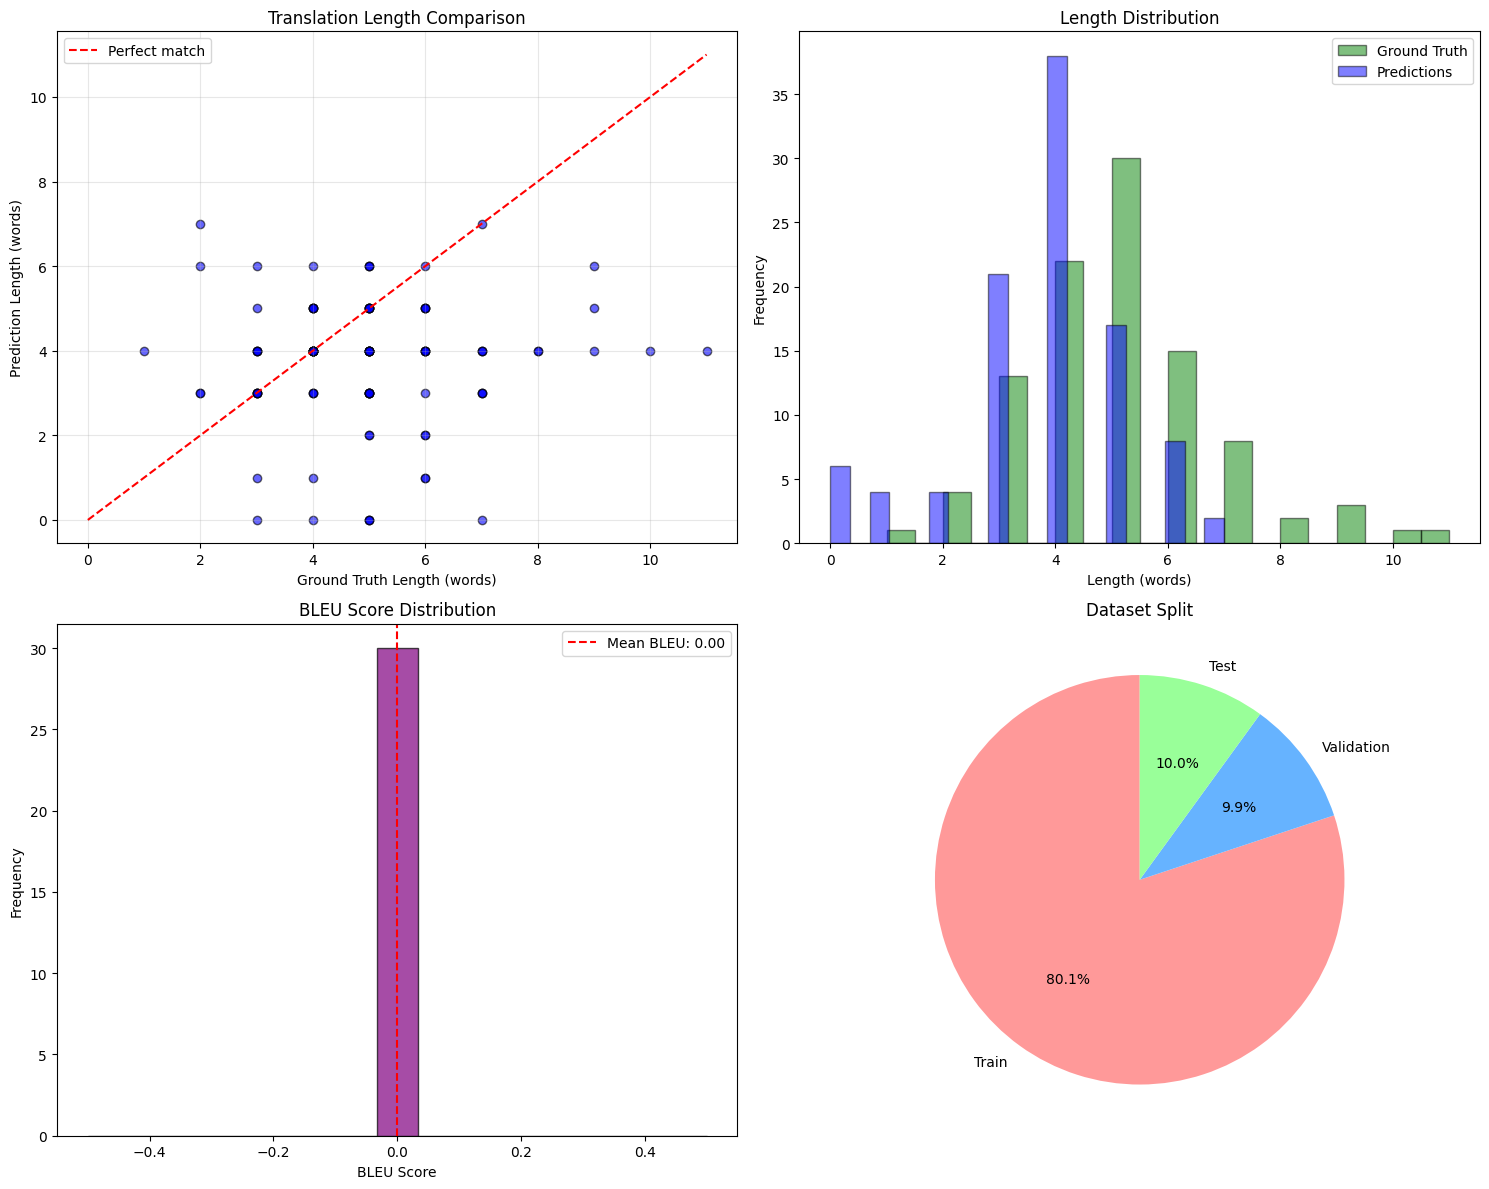

✓ Visualizations created successfully!
 Saved to: /kaggle/working/en_ur_translation_model/analysis_visualizations.png


In [77]:
# Cell 19: Create Visualizations (Updated)
import matplotlib.pyplot as plt
import numpy as np

print("Creating visualizations...")

# Reuse the 'evaluate' BLEU metric
import evaluate
bleu_metric = evaluate.load("sacrebleu")

# --- 1. Translation length comparison ---
sample_for_viz = test_df.sample(n=min(100, len(test_df)), random_state=42)
sample_predictions = translate_batch(sample_for_viz['english'].tolist(), batch_size=8)

pred_lengths = [len(pred.split()) for pred in sample_predictions]
ref_lengths = [len(ref.split()) for ref in sample_for_viz['urdu'].tolist()]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (A) Length comparison scatter plot
axes[0, 0].scatter(ref_lengths, pred_lengths, alpha=0.6, c='blue', edgecolors='black')
axes[0, 0].plot([0, max(ref_lengths)], [0, max(ref_lengths)], 'r--', label='Perfect match')
axes[0, 0].set_xlabel('Ground Truth Length (words)')
axes[0, 0].set_ylabel('Prediction Length (words)')
axes[0, 0].set_title('Translation Length Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (B) Length distribution comparison
axes[0, 1].hist(ref_lengths, bins=20, alpha=0.5, label='Ground Truth', color='green', edgecolor='black')
axes[0, 1].hist(pred_lengths, bins=20, alpha=0.5, label='Predictions', color='blue', edgecolor='black')
axes[0, 1].set_xlabel('Length (words)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Length Distribution')
axes[0, 1].legend()

# (C) BLEU score distribution (sample-level)
sample_bleu_scores = []
for i in range(min(30, len(sample_for_viz))):
    pred = [sample_predictions[i].strip()]
    ref = [[sample_for_viz.iloc[i]['urdu'].strip()]]
    score = bleu_metric.compute(predictions=pred, references=ref)['score']
    sample_bleu_scores.append(score)

axes[1, 0].hist(sample_bleu_scores, bins=15, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(np.mean(sample_bleu_scores), color='red', linestyle='--', 
                    label=f'Mean BLEU: {np.mean(sample_bleu_scores):.2f}')
axes[1, 0].set_xlabel('BLEU Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('BLEU Score Distribution')
axes[1, 0].legend()

# (D) Dataset split visualization
splits = ['Train', 'Validation', 'Test']
sizes = [len(train_df), len(val_df), len(test_df)]
colors = ['#ff9999', '#66b3ff', '#99ff99']
axes[1, 1].pie(sizes, labels=splits, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Dataset Split')

plt.tight_layout()
plt.savefig(f"{output_dir}/analysis_visualizations.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations created successfully!")
print(f" Saved to: {output_dir}/analysis_visualizations.png")


In [80]:
# Cell 20: Save and Load Model Functions (Fixed & Complete)
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import torch
import os
import json

def save_model_checkpoint(model, tokenizer, save_path, metadata=None):
 
    os.makedirs(save_path, exist_ok=True)
    
    # Save model and tokenizer
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    
    # Save metadata (if provided)
    if metadata:
        with open(os.path.join(save_path, 'training_metadata.json'), 'w') as f:
            json.dump(metadata, f, indent=2)
    
    print(f" Model and tokenizer saved to: {save_path}")
    if metadata:
        print(f" Metadata keys saved: {list(metadata.keys())}")


def load_model_checkpoint(load_path, device=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Load model + tokenizer
    loaded_model = MBartForConditionalGeneration.from_pretrained(load_path)
    loaded_tokenizer = MBart50TokenizerFast.from_pretrained(load_path)
    
    # Configure language codes
    loaded_tokenizer.src_lang = "en_XX"
    loaded_tokenizer.tgt_lang = "ur_PK"
    
    # Move to device
    loaded_model = loaded_model.to(device)
    
    # Load metadata (if exists)
    metadata_path = os.path.join(load_path, "training_metadata.json")
    metadata = None
    if os.path.exists(metadata_path):
        with open(metadata_path, "r") as f:
            metadata = json.load(f)
        print(f" Model loaded from: {load_path}")
        print(f" Metadata:\n{json.dumps(metadata, indent=2)}")
    else:
        print(f" Model loaded from: {load_path}")
    
    return loaded_model, loaded_tokenizer, metadata



metadata = {
    "model_type": "mBART-50",
    "source_language": "English",
    "target_language": "Urdu",
    "training_samples": len(train_df),
    "validation_samples": len(val_df),
    "test_samples": len(test_df),
    "test_bleu": test_results.get("test_bleu", "N/A") if 'test_results' in locals() else "N/A",
    "epochs": getattr(training_args, "num_train_epochs", "N/A"),
    "learning_rate": getattr(training_args, "learning_rate", "N/A")
}

save_path = f"{output_dir}/final_model"
save_model_checkpoint(model, tokenizer, save_path, metadata)

print("\n To load the model later, run:")
print(f"  loaded_model, loaded_tokenizer, metadata = load_model_checkpoint('{save_path}')")
print("\nThen translate like this:")
print("  translation = translate_text('I am Waseem')")


 Model and tokenizer saved to: /kaggle/working/en_ur_translation_model/final_model
 Metadata keys saved: ['model_type', 'source_language', 'target_language', 'training_samples', 'validation_samples', 'test_samples', 'test_bleu', 'epochs', 'learning_rate']

 To load the model later, run:
  loaded_model, loaded_tokenizer, metadata = load_model_checkpoint('/kaggle/working/en_ur_translation_model/final_model')

Then translate like this:
  translation = translate_text('I am Waseem')
